# Looking at data from Bell Field

This is code for looking at the continous HOBO data against the manual field measurements for one Bell Field Piezometer. The notebook is written for piezometer one (P1), so change the variables to match your actual column names.

In [109]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.dates as mdates

The code chunk below installs the package that runs a hampel filter--this is what cleans the spikes out of the data caused by removing the hobo sensors from the wells. After running it once, the package is installed in your environment, and you should comment out the cell to keep your cache clear.

In [110]:
# pip install hampel

In [111]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [112]:
import os # Allows python to communicate directly with the computer's operating system

# Reading in the Hobo data

In [121]:
# Import P1_current.csv, the file with all updated P1 data as "P1hobodf"
P1hobodf = pd.read_csv('P1_current.csv')
P1hobodf = P1hobodf.dropna()

# Change the 'Date-Time' column to the pandas datetime format
P1hobodf['Date-Time'] = pd.to_datetime(P1hobodf['Date-Time']) 
# Index P1hobodf by the datetime with a Pandas Datetimeindex. This allows us to reassign the correct dates after passing the data through the hampel filter.
P1hobodf.index = pd.DatetimeIndex(P1hobodf['Date-Time']) 

In [122]:
# Run P1hobodf to get a summary of the first and last five rows in P1hobodf. 
# Alternatively, use P1hobodf.head() to see the first five or P1hobodf.tail() to see the last five.
P1hobodf

,Date-Time,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids
Date-Time,,,,,,
2024-11-06 14:16:29,2024-11-06 14:16:29,13.780000,3.500000,4.500000,0.010000,2.260000
2024-11-06 14:31:29,2024-11-06 14:31:29,15.170000,531.200000,669.400000,0.320000,345.270000
2024-11-06 14:46:29,2024-11-06 14:46:29,15.230000,532.800000,670.400000,0.320000,346.320000
2024-11-06 15:01:29,2024-11-06 15:01:29,15.190000,533.400000,671.900000,0.320000,346.720000
2024-11-06 15:16:29,2024-11-06 15:16:29,15.130000,533.400000,672.800000,0.320000,346.710000
...,...,...,...,...,...,...
2026-07-21 08:15:00,2026-07-21 08:15:00,15.283695,656.992676,825.411682,0.398047,427.045227
2026-07-21 08:30:00,2026-07-21 08:30:00,15.283695,656.970642,825.383972,0.398033,427.030914
2026-07-21 08:45:00,2026-07-21 08:45:00,15.283695,657.136780,825.592712,0.398137,427.138885


# Filtering the data

A hampel filter uses a running average to compute outliers in time-dependent data. Instead of dropping outliers, it replaces them with the local median. Visit https://www.mathworks.com/help/signal/ref/hampel.html for more information.

In [123]:
# Run the filter on the Temperature column. This produces a type of data called a "hampel.result.Result". 
# The window size is the number of neighbors (k) on either side of the sample. Default k=3.
# The n_sigma is the number of standard deviations by which a sample must differ from the local median to be replaced with that median. Default nsigma=3.
P1filtered = hampel(P1hobodf['Temperature'], window_size=6, n_sigma=1.5)

In [124]:
# The hampel result has an internal index that must be stripped away to add the data back into our data frame. 
# Rewrite P1filtered as a NumPy array, and then as a DataFrame with P1hobodf's original datetime index. Problem solved by Google Gemini.
P1filtered = pd.DataFrame(P1filtered.filtered_data.to_numpy(), index=P1hobodf.index)

In [125]:
# Add a column called "FilteredTemp" to the original P1hobodf dataframe with all the filtered data. This works because P1filtered is a dataframe with the same index.
P1hobodf['FilteredTemp'] = P1filtered

Repeat the filter for the Specific Conductivity data.

In [126]:
# Filter the SPC measurements.
P1filteredSPC = hampel(P1hobodf['Specific Conductivity'], window_size=6, n_sigma=1.5)
P1filteredSPC = pd.DataFrame(P1filteredSPC.filtered_data.to_numpy(), index=P1hobodf.index)
P1hobodf['FilteredSPC'] = P1filteredSPC

The hampel filter pads the data set with zeroes in order to replace the values on the ends, which can make the first and last values too low. Slice off the first and last measurement in the data set.

In [127]:
# Overwrites P1hobodf without the first and last rows. 
P1hobodf = P1hobodf.iloc[1:-1]

# Add in the other datasets

In [81]:
# Add the manual YSI data.
P1mandf = pd.read_csv('Manual_Data_P1.csv', index_col=False) 
P1mandf['Date'] = pd.to_datetime(P1mandf['Date']) 

In [82]:
# Add the NOAA air temp data.
weatherdf = pd.read_csv('NOAAHastingsDamTemp.csv')
weatherdf['Date'] = pd.to_datetime(weatherdf['Date'])

The creek data also has to be filtered for spikes. In the case of P1, there is a temperature dot next to the well (called C1) and an MX801 conductivity logger a few yards downstream (called downst).

In [129]:
# Add in C1.
C1hobodf = pd.read_csv('P1_creek_current.csv') 
C1hobodf['Date-Time'] = pd.to_datetime(C1hobodf['Date-Time']) 
C1hobodf.index = pd.DatetimeIndex(C1hobodf['Date-Time'])

In [130]:
# Filter C1 the same way as P1.
C1filtered = hampel(C1hobodf['Temperature'], window_size=6, n_sigma=1.5)
C1filtered = pd.DataFrame(C1filtered.filtered_data.to_numpy(), index=C1hobodf.index)
C1hobodf['FilteredTemp'] = C1filtered

In [131]:
# Slices the padded values from C1hobodf (the first and last rows). 
C1hobodf = C1hobodf.iloc[1:-1]

In [132]:
# Add in downstream conductivity monitor.
downst = pd.read_csv('Dwnstrm_current.csv') 
downst['Date-Time'] = pd.to_datetime(downst['Date-Time']) 
downst.index = pd.DatetimeIndex(downst['Date-Time'])

In [133]:
# Filter downst.
downfilt = hampel(downst['Temperature'], window_size=6, n_sigma=1.5)
downfilt = pd.DataFrame(downfilt.filtered_data.to_numpy(), index=downst.index)
downst['FilteredTemp'] = downfilt

In [134]:
downfilt = hampel(downst['Specific Conductivity'], window_size=6, n_sigma=1.5)
downfilt = pd.DataFrame(downfilt.filtered_data.to_numpy(), index=downst.index)
downst['FilteredSPC'] = downfilt

In [135]:
# Slices the padded values from downst (the first and last rows). 
downst = downst.iloc[1:-1]

# Plot the data

There are a lot of things to visualize! I've tried to lay out everything that I find most helpful, but you will have to play around a bit to see for yourself.

Here is a key:  
  
fig, ax=plt.subplots(figsize = [adjustable dimension])  
ax.plot(x, y, 'shape of marker', color='[whatever color you want]', alpha = [less than 1 is transparent], label='[the name of the thing you are plotting]')  
ax.scatter(x, y, s= [smaller number makes a smaller dot], color='[]', alpha = [], label='[]')

Plotting temperature:

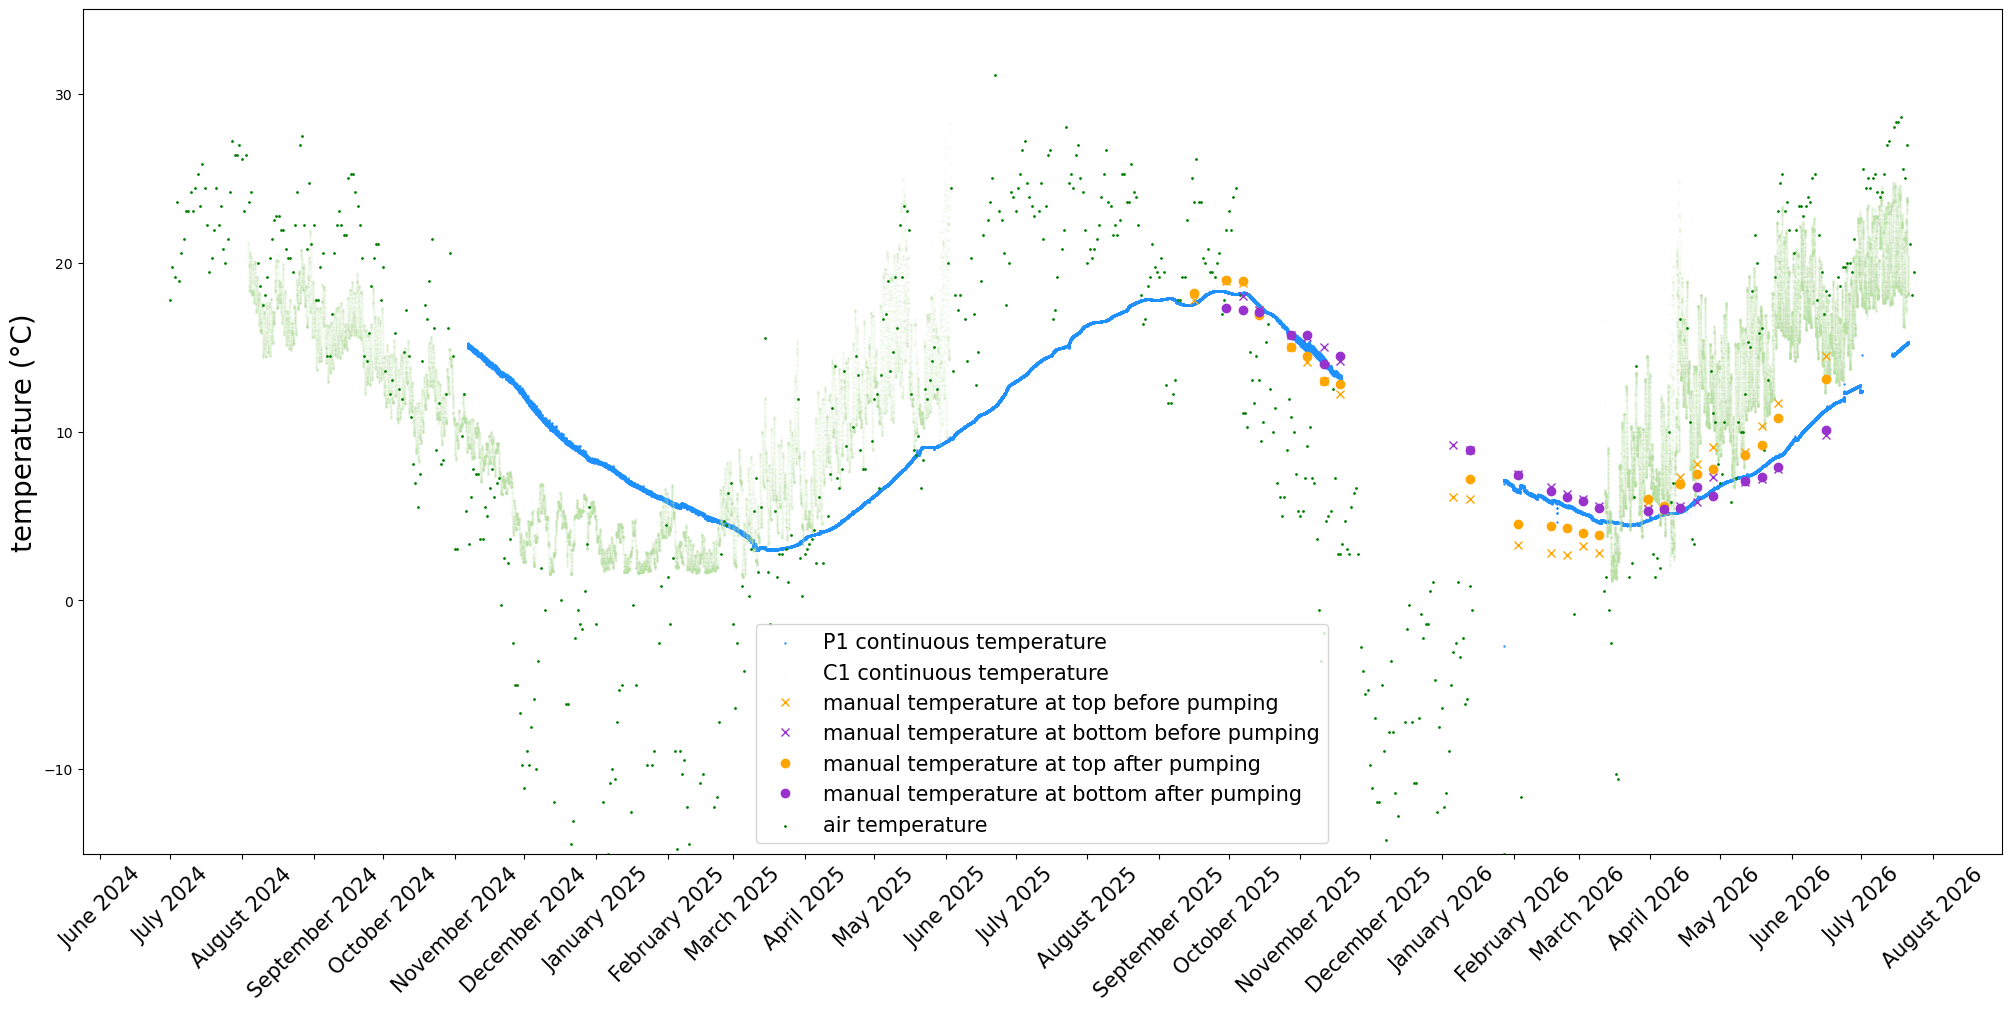

In [136]:

fig, ax = plt.subplots(layout='constrained', figsize=(20,10))

# Plot P1hobodf as a scatter plot with tiny dots
ax.scatter(P1hobodf.index, P1hobodf.FilteredTemp, color="dodgerblue", s = 0.5, label = "P1 continuous temperature")

# Plot the creek temperature as a scatter plot with tiny, transparent dots.
ax.scatter(C1hobodf.index, C1hobodf.FilteredTemp, color = "xkcd:light grey green", alpha = 0.2, s = 0.2, label = "C1 continuous temperature")

# Plot all of the manual data. 
ax.plot(P1mandf.Date, P1mandf.loc[:,"Temp top before"], 'x', color = "orange", label = "manual temperature at top before pumping")
ax.plot(P1mandf.Date, P1mandf.loc[:,"Temp bottom before"], 'x', color = "darkorchid", label = "manual temperature at bottom before pumping")
ax.plot(P1mandf.Date, P1mandf.loc[:,"Temp top after"], 'o', color = "orange", label = "manual temperature at top after pumping")
ax.plot(P1mandf.Date, P1mandf.loc[:,"Temp bottom after"], 'o', color = "darkorchid", label = "manual temperature at bottom after pumping")

# Plot the weather data as a scatter plot with slightly larger dots.
ax.scatter(weatherdf.Date, weatherdf.MeanTempC, color = "green", s = 1, label = "air temperature")

# Instead of labelling the x axis with the datetime, corellate the datetime with a string that gives Month and Year.
ax.xaxis.set_major_locator(mdates.MonthLocator())
# '%B %Y' can be adjusted. %d calls the day in digits, etc. 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))

# Rotate the labels.
plt.xticks(rotation=45, fontsize = 15)
# plt.xlabel("time", fontsize = 15)
plt.ylabel("temperature (°C)", fontsize = 20) #Temperature (°C) is a placeholder.

# Ajust the limits to zoom in and out on time periods you'd like to look at in higher resolution.
# plt.xlim((pd.to_datetime("2025-11-18 06"), pd.to_datetime("2025-11-18 16")))
plt.ylim(-15, 35)

# I haven't found a seamless way to code the legend into exactly the spot I want, but here are some of the better ones.
ax.legend(fontsize=15)
# plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left", fontsize = 20)

plt.show()

Plotting SPC:

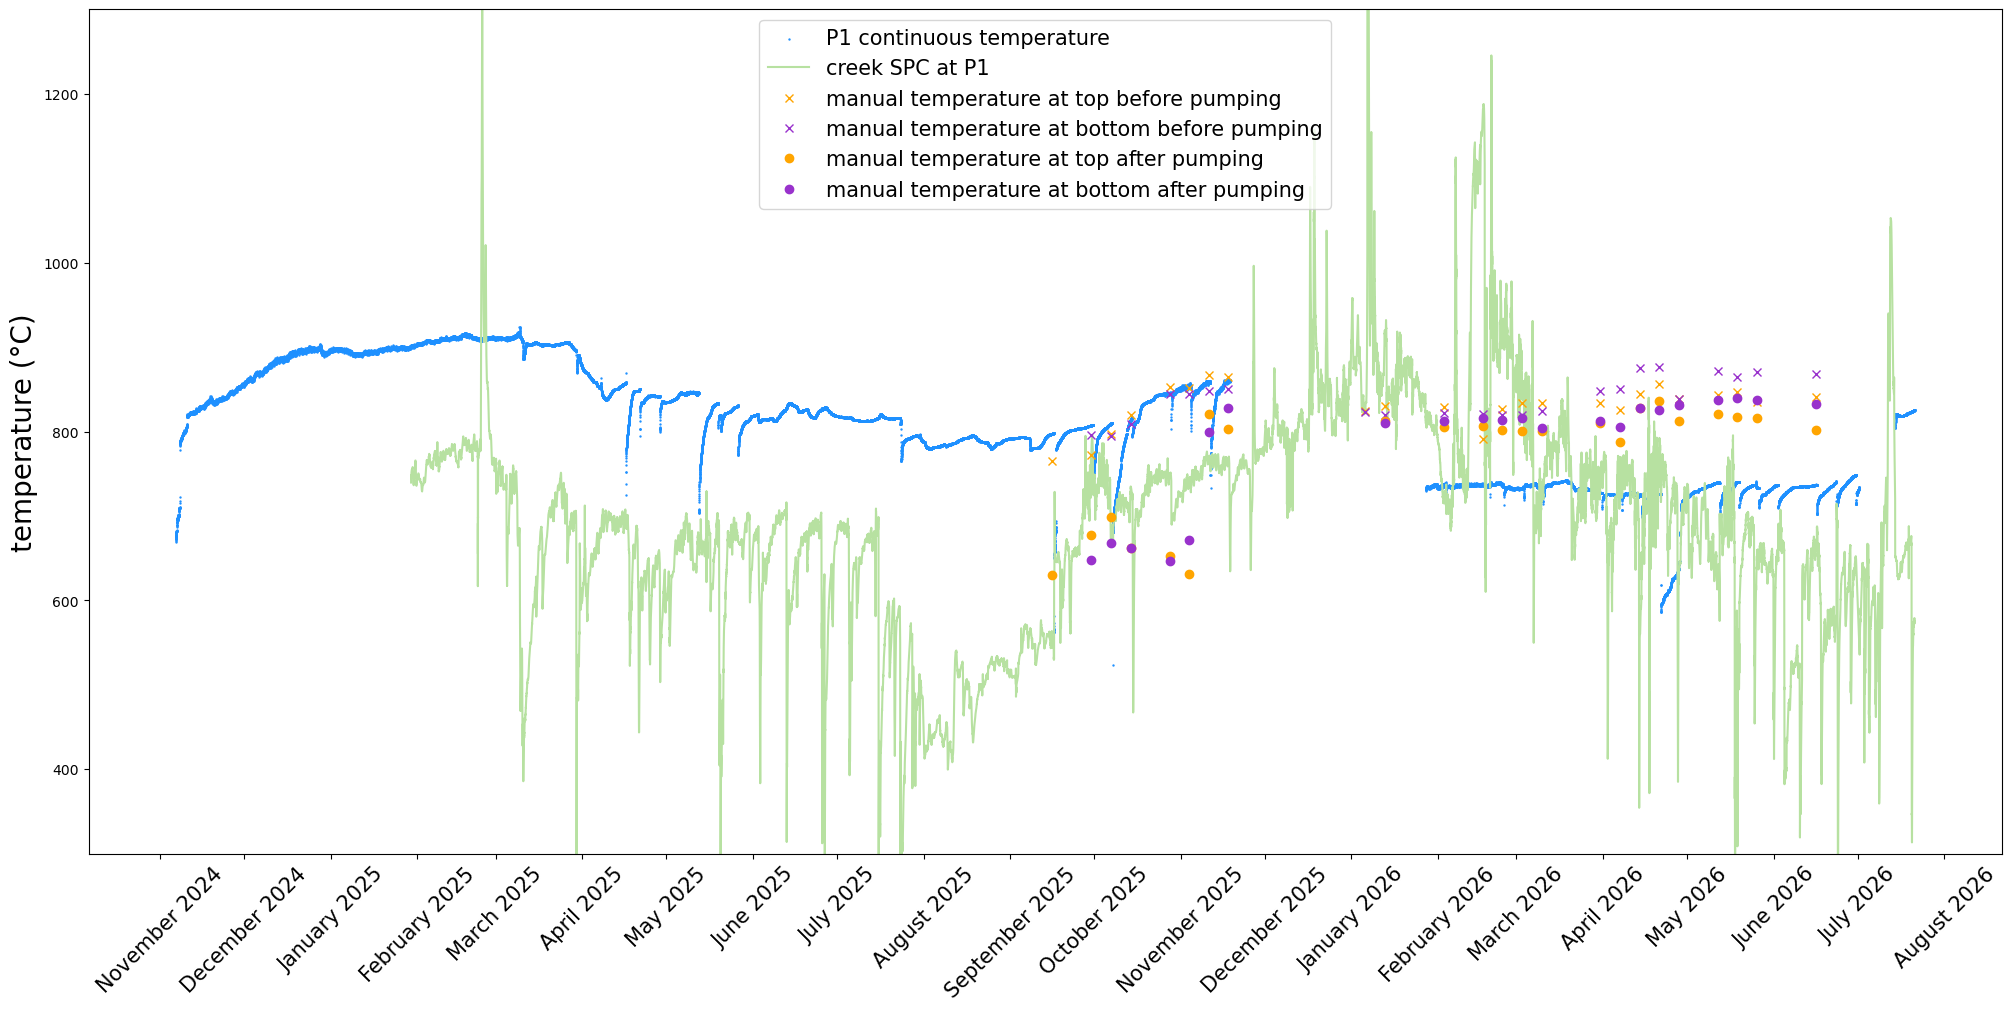

In [137]:

fig, ax = plt.subplots(layout='constrained', figsize=(20,10))

# Plot P1hobodf as a scatter plot with tiny dots.
ax.scatter(P1hobodf.index, P1hobodf.FilteredSPC, color="dodgerblue", s = 0.5, label = "P1 continuous temperature")

# Plot the creek conductivity.
ax.plot(downst.index, downst.FilteredSPC, color = "xkcd:light grey green", label = 'creek SPC at P1')

# Plot all of the manual data. 
ax.plot(P1mandf.Date, P1mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual temperature at top before pumping")
ax.plot(P1mandf.Date, P1mandf.loc[:,"SPC bottom before"], 'x', color = "darkorchid", label = "manual temperature at bottom before pumping")
ax.plot(P1mandf.Date, P1mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual temperature at top after pumping")
ax.plot(P1mandf.Date, P1mandf.loc[:,"SPC bottom after"], 'o', color = "darkorchid", label = "manual temperature at bottom after pumping")


# Instead of labelling the x axis with the datetime, corellate the datetime with a string that gives Month and Year.
ax.xaxis.set_major_locator(mdates.MonthLocator())
# '%B %Y' can be adjusted. %d calls the day in digits, etc. 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))

# Rotate the labels.
plt.xticks(rotation=45, fontsize = 15)
# plt.xlabel("time", fontsize = 15)
plt.ylabel("temperature (°C)", fontsize = 20) #Temperature (°C) is a placeholder.

# Ajust the limits to zoom in and out on time periods you'd like to look at in higher resolution.
# plt.xlim((pd.to_datetime("2025-11-18 06"), pd.to_datetime("2025-11-18 16")))
plt.ylim(300, 1300)

# I haven't found a seamless way to code the legend into exactly the spot I want, but here are some of the better ones.
ax.legend(fontsize=15)
# plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left", fontsize = 20)

plt.show()

# Other cool plots

Plotting SPC against rainfall:

In [138]:
# Add precipitation data:
precip = pd.read_csv('NOAAFaribaultPrecipitation.csv')
precip['Date'] = pd.to_datetime(precip['Date'])
precip = precip[precip['PrecipitationCM'] != 0]

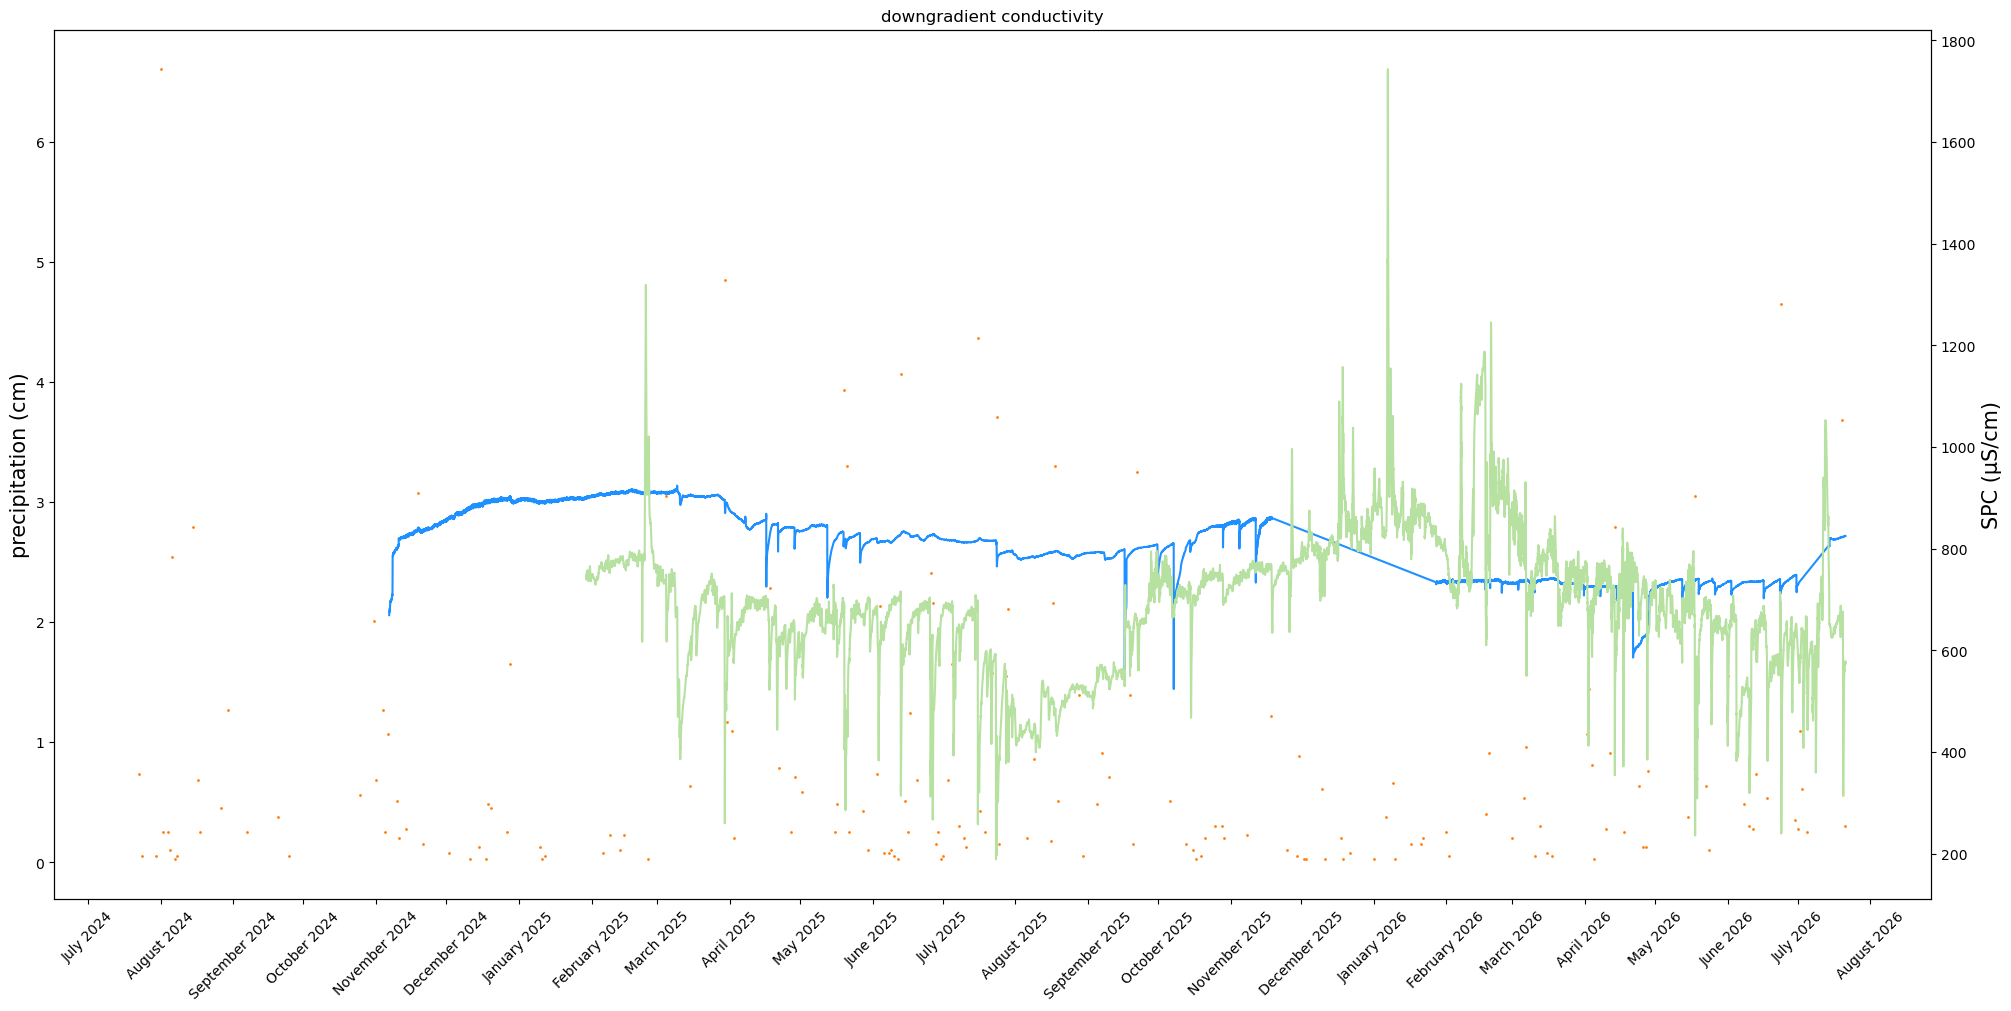

In [139]:
fig, ax1 = plt.subplots(layout='constrained', figsize=(20,10))
# ax1.set_xlabel('Date')
ax1.set_ylabel('precipitation (cm)', fontsize = 15)
rain = ax1.scatter(precip.Date, precip.PrecipitationCM, alpha = 1, s= 1, color = 'tab:orange', label = 'precipitation (cm)')
# ax.scatter(weatherdf.Date, weatherdf.loc[:,'Mean  Celcius Teperature'], color = 'green', s = 1, label = 'air temperature')

ax1.tick_params(axis='x', rotation=45)
# ax1.set_ylim(0, 3)
# Instead of labelling the x axis with the datetime, corellate the datetime with a string that gives Month and Year.
ax1.xaxis.set_major_locator(mdates.MonthLocator())
# '%B %Y' can be adjusted. %d calls the day in digits, etc. 
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))

ax2 = ax1.twinx() 
ax2.set_ylabel('SPC (µS/cm)', fontsize = 15) 
P5 = ax2.plot(P1hobodf.index, P1hobodf.FilteredSPC, color='dodgerblue', label = 'P5 continuous SPC')
C5 = ax2.plot(downst.index, downst.FilteredSPC,  color = 'xkcd:light grey green', label = 'creek SPC at P5')
# ax2.set_ylim(0, 1000)
# ax2.set_xlim((pd.to_datetime('2025-07-01'), pd.to_datetime('2025-07-22')))

plt.xticks(rotation=45)
# plt.xlabel('Year-Month')
# plt.ylabel('SPC (µS/cm)')
plt.title('downgradient conductivity')
# leg = rain + C5 + C1
# labs = [l.get_label() for l in leg]
# ax1.legend(leg, labs)

# plt.xlim(pd.to_datetime('2025-04'), pd.to_datetime('2025-05'))

plt.show();

Cleaning the data further: Because the Hobos take measurements on offset 15-min intervals, it can be helpful to reassign the timestamps to the nearest 15 minutes. 

In [140]:
# Resample the piezometer data.
P1hobodf.set_index('Date-Time', inplace=True)
P1hobodf.index = P1hobodf.index.round('15min')

In [141]:
# Resample the stream data.
downst.set_index('Date-Time', inplace=True)
downst.index = downst.index.round('15min')

The Hobos are set to adjust for daylight savings time, so once a year, on November 2, they each record 1-2 am twice. On March 9, they miss the hour completely.

In [142]:
# Run df.index.is_unique to see if the dataframe has daylight savings duplicates. 
P1hobodf.index.is_unique

False

In [143]:
# If is_unique returns 'False', print the duplicate rows to check that it is the daylight savings day and not a different error.
duplicate_rows = P1hobodf.loc[P1hobodf.index.duplicated()]
print(duplicate_rows)


                     Temperature  Electrical Conductivity  \
Date-Time                                                   
2025-11-02 01:00:00        14.99                    674.1   
2025-11-02 01:15:00        15.19                    676.3   
2025-11-02 01:30:00        15.26                    676.5   
2025-11-02 01:45:00        15.10                    673.2   

                     Specific Conductivity  Salinity  Total Dissolved Solids  \
Date-Time                                                                      
2025-11-02 01:00:00                  853.5      0.41                  438.18   
2025-11-02 01:15:00                  851.7      0.41                  439.59   
2025-11-02 01:30:00                  850.6      0.41                  439.74   
2025-11-02 01:45:00                  849.9      0.41                  437.58   

                     FilteredTemp  FilteredSPC  
Date-Time                                       
2025-11-02 01:00:00         14.99   853.500000  
2025-

In [144]:
# For ease, I just delete the four rows that correspond to the second 1 am hour on November 2. 
P1hobodf = P1hobodf.loc[~P1hobodf.index.duplicated(keep='first')]

In [145]:
# Check the creek data for the same error. If it exists, run .index.duplicated(keep='first') to remove it.
downst = downst.loc[~downst.index.duplicated(keep='first')]

# Plotting the creek and piezometer against each other:

To plot the creek and piezometer against each other, you have to line up the two dataframes by their indeces. This will clip the larger data set to the smaller one. 

In [146]:
# Reindex the piezometer (larger df) to line up with the creek. This makes the two dataframes line up row by row with the same datetime stamps.
P1hobodf = P1hobodf.reindex_like(downst, method = None)

In [147]:
# run df.head() for each df and print their shapes to double check that you reindexed correctly.
print('downst shape:', downst.FilteredSPC.shape, 'Total size:', downst.FilteredSPC.size)
print('piezo shape:', P1hobodf.FilteredSPC.shape, 'Total size:', P1hobodf.FilteredSPC.size)

downst shape: (51473,) Total size: 51473
piezo shape: (51473,) Total size: 51473


In [148]:
# Create a column 'mos' in P1hobodf that is the spring form of the month and year from each measurement
P1hobodf['mos'] = P1hobodf.index.to_period('M')
P1hobodf['mos'] = P1hobodf.mos.dt.strftime('%B %Y')

In [149]:
# Create a column 'mos' in downst that is the spring form of the month and year from each measurement
downst['mos'] = downst.index.to_period('M')
downst['mos'] = downst.mos.dt.strftime('%B %Y')

Create a dictionary to color-code the data by month.

In [150]:
# Create a variable that is a list of all of the months during which data was collected (from the column 'mos'). 
month = downst.mos.unique()

In [151]:
print(month)

<StringArray>
[  'January 2025',  'February 2025',     'March 2025',     'April 2025',
       'May 2025',      'June 2025',      'July 2025',    'August 2025',
 'September 2025',   'October 2025',  'November 2025',  'December 2025',
   'January 2026',  'February 2026',     'March 2026',     'April 2026',
       'May 2026',      'June 2026',      'July 2026']
Length: 19, dtype: str


In [152]:
# Create a dictionary assigning each a color. This is a perceptually uniform list of rainbow-order colors.
# Earlier dates are reds, later is purples. 
colors = {'January 2025':'#ff5e00', 'February 2025':'#ffa400', 'March 2025': '#ffea00', 'April 2025':'#cdff00', 'May 2025':'#8dff00', 'June 2025':'#46ff00', 'July 2025':'#00ff00', 'August 2025':'#00ff46', 'September 2025':'#00ff8c', 'October 2025':'#00ffcc', 'November 2025': '#00ecff', 'December 2025':'#00a5ff', 'January 2026':'#005eff', 'February 2026':'#0018ff', 'March 2026':'#2a00ff', 'April 2026':'#7000ff', 'May 2026':'#b700ff', 'June 2026':'#fe00ff', 'July 2026':'#ff00bf'}

Make a new dataframe (here I called it stat1, for station 1) that is the two dataframes merged.

In [153]:
stat1 = pd.merge(downst, P1hobodf, on = 'Date-Time')

Plot the stream conductivity against the piezometer conductivity. This helps look at relationships between the two.

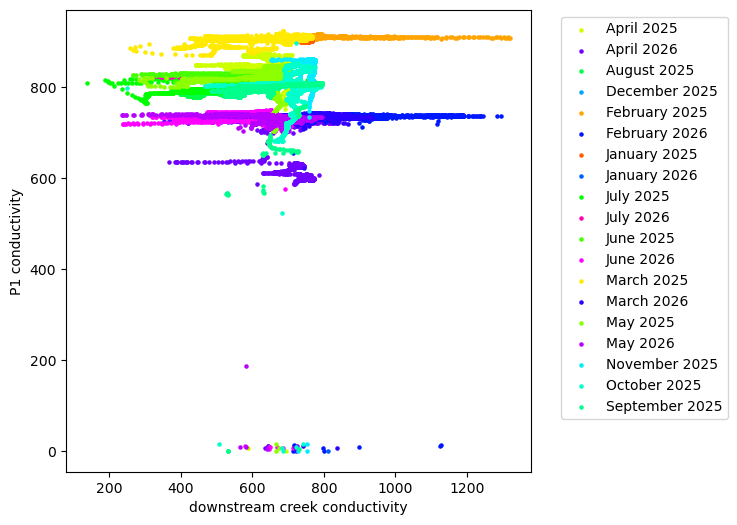

In [156]:
# Source - https://stackoverflow.com/a/26139658
# Posted by Ffisegydd, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-29, License - CC BY-SA 4.0

fig, ax = plt.subplots(figsize=(6, 6))

grouped = stat1.groupby('mos_x')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='Specific Conductivity_x', y='Specific Conductivity_y', s = 5, label=key, color=colors[key])

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel('P1 conductivity')
plt.xlabel('downstream creek conductivity')
plt.show()